In [18]:
from __future__ import annotations
import hashlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import TrainingArguments
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET = "Tobi-Bueck/customer-support-tickets"


def read_idx(path: Path) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.int64)
    return arr


def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()


def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out


def basic_eda(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== SIZES ===")
    for k, d in splits.items():
        print(f"{k}: {len(d)}")

    print("\n=== MISSING VALUES (share) ===")
    cols = ["subject", "body", "queue", "priority", "type", "language"]
    for k, d in splits.items():
        miss = {c: float(d[c].isna().mean()) if c in d.columns else 1.0 for c in cols}
        print(k, {c: round(miss[c], 4) for c in cols})

    # text lengths
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        lens = txt.str.len()
        ws_tokens = txt.str.split().map(len)
        print(f"\n=== TEXT LENGTHS ({k}) ===")
        print(f"chars:  mean={lens.mean():.1f}  p50={lens.median():.0f}  p90={lens.quantile(0.9):.0f}  p99={lens.quantile(0.99):.0f}")
        print(f"words:  mean={ws_tokens.mean():.1f}  p50={ws_tokens.median():.0f}  p90={ws_tokens.quantile(0.9):.0f}  p99={ws_tokens.quantile(0.99):.0f}")

    # language dist
    print("\n=== LANGUAGE DISTRIBUTION ===")
    for k, d in splits.items():
        c = d["language"].fillna("NA").value_counts(normalize=True)
        print(k, {i: round(float(v), 4) for i, v in c.items()})

    # class coverage + tails
    for target in ["queue", "priority", "type"]:
        print(f"\n=== CLASS COVERAGE: {target} ===")
        train_labels = set(splits["train"][target].astype(str))
        for k, d in splits.items():
            labels = set(d[target].astype(str))
            missing_vs_train = sorted(list(train_labels - labels))
            print(f"{k}: classes={len(labels)}  missing_vs_train={len(missing_vs_train)}")

        # tail in train
        vc = splits["train"][target].astype(str).value_counts()
        print("train top-10:", list(zip(vc.head(10).index.tolist(), vc.head(10).tolist())))
        print("train bottom-10:", list(zip(vc.tail(10).index.tolist(), vc.tail(10).tolist())))


def duplicate_checks(splits: dict[str, pd.DataFrame]) -> None:
    print("\n=== DUPLICATE TEXT CHECKS (MD5 of subject+body) ===")
    hashes = {}
    for k, d in splits.items():
        txt = (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)
        h = txt.map(md5)
        hashes[k] = set(h.tolist())
        dup_within = 1.0 - (len(hashes[k]) / len(d))
        print(f"{k}: unique={len(hashes[k])}/{len(d)}  within-dup-rate={dup_within:.4f}")

    inter_tv = len(hashes["train"] & hashes["val"])
    inter_tt = len(hashes["train"] & hashes["test"])
    inter_vt = len(hashes["val"] & hashes["test"])
    print(f"cross-dup hashes: train∩val={inter_tv}, train∩test={inter_tt}, val∩test={inter_vt}")

    if inter_tv or inter_tt or inter_vt:
        print("[WARN] Есть одинаковые тексты между сплитами (возможна утечка/слишком похожие письма).")
    else:
        print("[OK] Межсплитовых текстовых дублей не найдено.")


repo_root = Path(".").resolve()

ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()
splits = split_df(df, repo_root)

for k in splits:
    splits[k]["type"] = splits[k]["type"].fillna("Unknown")

print("Данные успешно загружены в словарь 'splits'!")

Данные успешно загружены в словарь 'splits'!


In [19]:
splits

{'train':                                                  subject  \
 0                        Wesentlicher Sicherheitsvorfall   
 1                                     Account Disruption   
 2      Query About Smart Home System Integration Feat...   
 3                      Inquiry Regarding Invoice Details   
 4      Question About Marketing Agency Software Compa...   
 ...                                                  ...   
 61760     Assistance Needed for IFTTT Docker Integration   
 61761        Bitten um Unterstützung bei der Integration   
 61762                                               None   
 61763            Hilfe bei digitalen Strategie-Problemen   
 61764  Optimierung Ihrer Datenanalyse-Plattform erlei...   
 
                                                     body  \
 0      Sehr geehrtes Support-Team,\n\nich möchte eine...   
 1      Dear Customer Support Team,\n\nI am writing to...   
 2      Dear Customer Support Team,\n\nI hope this mes...   
 3      Dear 

In [20]:
basic_eda(splits)
duplicate_checks(splits)


=== SIZES ===
train: 49412
val: 6176
test: 6177

=== MISSING VALUES (share) ===
train {'subject': 0.0864, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.0818, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0852, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== TEXT LENGTHS (train) ===
chars:  mean=464.8  p50=460  p90=755  p99=999
words:  mean=62.4  p50=62  p90=99  p99=143

=== TEXT LENGTHS (val) ===
chars:  mean=466.7  p50=463  p90=753  p99=1010
words:  mean=62.7  p50=62  p90=98  p99=142

=== TEXT LENGTHS (test) ===
chars:  mean=460.3  p50=454  p90=751  p99=1015
words:  mean=62.1  p50=62  p90=98  p99=147

=== LANGUAGE DISTRIBUTION ===
train {'de': 0.5424, 'en': 0.4576}
val {'de': 0.5465, 'en': 0.4535}
test {'de': 0.5391, 'en': 0.4609}

=== CLASS COVERAGE: queue ===
train: classes=52  missing_vs_train=0
val: classes=52  missing_vs_train=0
test: classes=52  missing_vs

In [21]:
train = splits['train']
val = splits['val']
test = splits['test']

In [22]:
display(train[train['subject'].isna()], train[train['body'].isna()])

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
870,None,"Customer Support, I am requesting comprehensiv...",Please provide detailed integration instructio...,Request,Technical Support,high,en,52.0,Support,Documentation,Troubleshooting,Integration,Configuration,Database,Guidance,Best Practices
887,None,"Customer Support,\n\nI am reporting a critical...","<name>, I regret to hear about the security br...",Incident,Technical Support,high,en,52.0,Security,Outage,Disruption,Recovery,IT,Tech Support,None,None
888,None,Die Leistung der digitalen Kampagnen unserer M...,Überprüfen Sie die Kampagnenberichte und verei...,Incident,Customer Service,medium,de,52.0,Performance,Outage,Disruption,Recovery,Security,None,None,None
915,None,"Customer Support, drafting a request for enhan...","<name>, thank you for your email regarding the...",Change,Customer Service,medium,en,52.0,Feature,Performance,Feedback,Data Analytics,Investment,Decision Making,None,None
929,None,Customer support has received a report regardi...,We have received a report about a security inc...,Incident,Billing and Payments,high,en,52.0,Security,Malware,Outage,Disruption,Recovery,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61695,None,"To Customer Support, I need help with a critic...","<name>, thank you for reporting the issue with...",Incident,Product Support,high,en,NaN,Bug,Performance,Feature,IT,Tech Support,None,None,None
61719,None,Looking for assistance in securing medical dat...,Can provide guidance on securing medical data ...,Request,Customer Service,medium,en,NaN,Security,Documentation,IT,Tech Support,None,None,None,None
61726,None,Ein kritischer Fehler ist während der Projektm...,Wir haben eine kritische Fehlermeldung für die...,Problem,Product Support,medium,de,NaN,Bug,Disruption,Performance,IT,Tech Support,None,None,None
61758,None,Can you provide information on digital strateg...,I would be happy to discuss digital strategies...,Request,Billing and Payments,medium,en,NaN,Feedback,Sales,Lead,None,None,None,None,None


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
59452,Moodle integration broke unexpectedly due to a...,None,Could you please offer more specific details?,Problem,Product Support,medium,en,NaN,Technical,Bug,Integration,Crash,Documentation,Maintenance,None,None
59724,Mehrmale Integrationsvorgänge gingen über Nach...,None,Ich werde mich gerne um den Fehler kümmern und...,Incident,Product Support,medium,de,NaN,Technical,Bug,API,Authentication,Outage,Resolution,Support,Crash


In [23]:
train.isna().sum()

,0
subject,4268
body,2
answer,10519
type,0
queue,0
priority,0
language,0
version,26488
tag_1,10508
tag_2,10555


In [24]:
display(train[(train['type'] == 'Unknown')], train[(train['type'] == 'Unknown') & (train['answer'].notna())])

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
28587,Betreff: Artikelaustausch,"Sehr geehrtes Support-Team,\n\nich melde ein P...",None,Unknown,Food & Drink/Groceries,medium,de,NaN,None,None,None,None,None,None,None,None
28589,Fehlfunktion des intelligenten Bewässerungssys...,"Ich schreibe Ihnen, um einen kritischen Ausfal...",None,Unknown,Home & Garden/Landscaping,high,de,NaN,None,None,None,None,None,None,None,None
28590,Problem mit KI-Alarmbenachrichtigungen,"Sehr geehrte Support-Mitarbeiter,\n\nich melde...",None,Unknown,IT & Technology/Hardware Support,medium,de,NaN,None,None,None,None,None,None,None,None
28591,Dringend: Schwerwiegender Serviceausfall gemeldet,"Sehr geehrtes Support-Team,\n\nWir melden eine...",None,Unknown,News,high,de,NaN,None,None,None,None,None,None,None,None
28592,Benötigte Unterstützung: Scanner-Fehlfunktion,"Sehr geehrtes Support-Team,\n\nich melde ein w...",None,Unknown,Shopping/Retail Stores,medium,de,NaN,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41759,Dringend: EcoLogix IoT System ausgefallen - CO...,"Sehr geehrte Support-Mitarbeiter,\n\nWir haben...",None,Unknown,Pets & Animals/Pet Services,critical,de,NaN,None,None,None,None,None,None,None,None
41761,Anfrage zum Zugriff auf Amtrak-Systemnutzungsb...,"Sehr geehrtes Support-Team,\n\nwir schreiben I...",None,Unknown,Travel & Transportation/Land Travel,very_low,de,NaN,None,None,None,None,None,None,None,None
41762,Unvollständige Zutaten in aktuellen HelloFresh...,"Sehr geehrtes Support-Team,\nich schreibe Ihne...",None,Unknown,Food & Drink/Groceries,medium,de,NaN,None,None,None,None,None,None,None,None
41763,Dringend: Ausfall des Slack Enterprise Grid Di...,"Sehr geehrte Damen und Herren vom Support,\n\n...",None,Unknown,Jobs & Education/Recruitment,high,de,NaN,None,None,None,None,None,None,None,None


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8


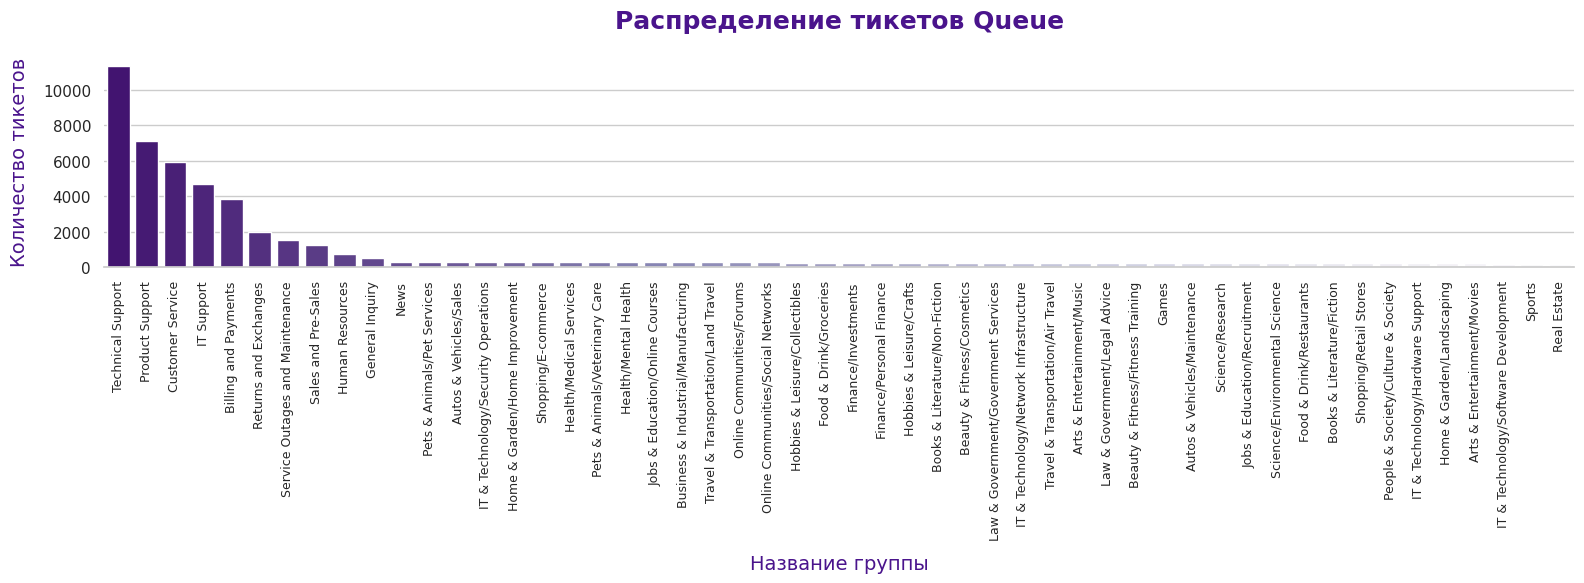

In [25]:
nclass = splits['train']['queue'].value_counts()

plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=nclass.index,
    y=nclass.values,
    hue=nclass.index,
    palette="Purples_r",
    legend=False
)

plt.title('Распределение тикетов Queue', fontsize=18, fontweight='bold', pad=20, color='#4a148c')
plt.xlabel('Название группы', fontsize=14, labelpad=10, color='#4a148c')
plt.ylabel('Количество тикетов', fontsize=14, labelpad=10, color='#4a148c')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=11)
sns.despine(top=True, right=True, left=True)
plt.tight_layout()
plt.show()

Наблюдается перекос количества тикетов в сторону нескольких крупных категорий queue

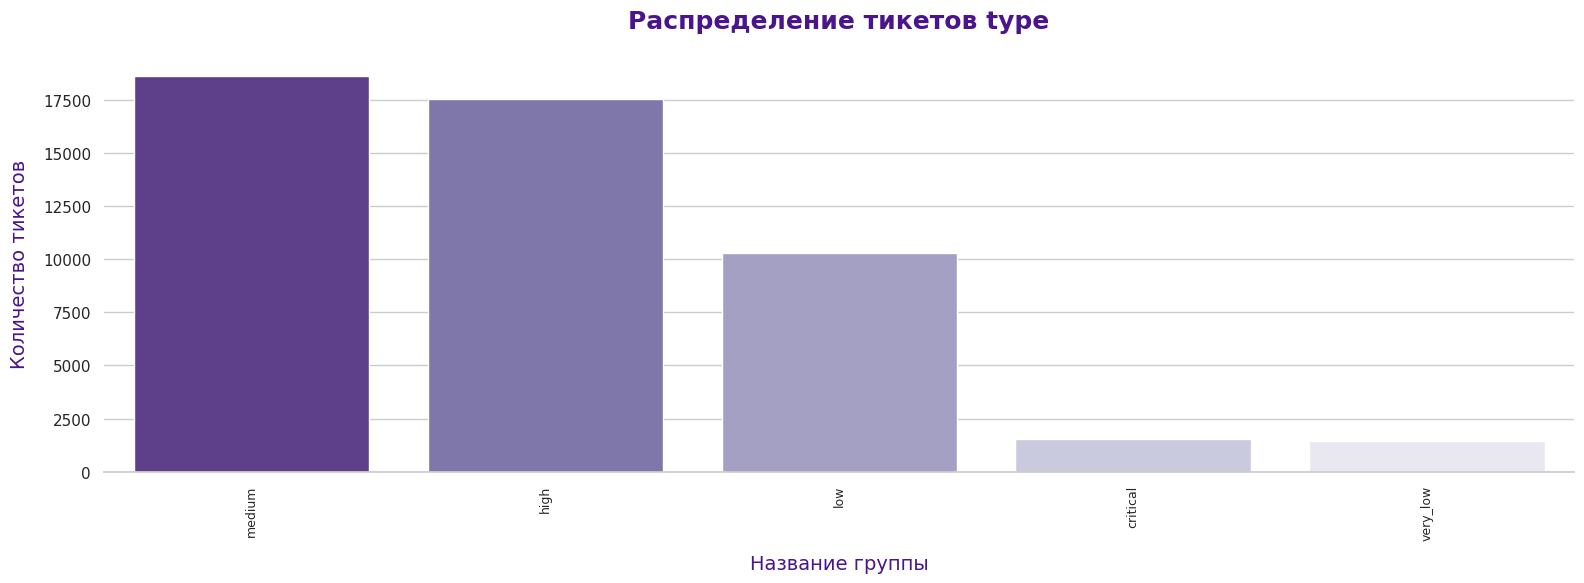

In [26]:
nclass = splits['train']['priority'].value_counts()

plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=nclass.index,
    y=nclass.values,
    hue=nclass.index,
    palette="Purples_r",
    legend=False,
)

plt.title('Распределение тикетов type', fontsize=18, fontweight='bold', pad=20, color='#4a148c')
plt.xlabel('Название группы', fontsize=14, labelpad=10, color='#4a148c')
plt.ylabel('Количество тикетов', fontsize=14, labelpad=10, color='#4a148c')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=11)
sns.despine(top=True, right=True, left=True)
plt.tight_layout()
plt.show()

Перекос в сторону medium и high

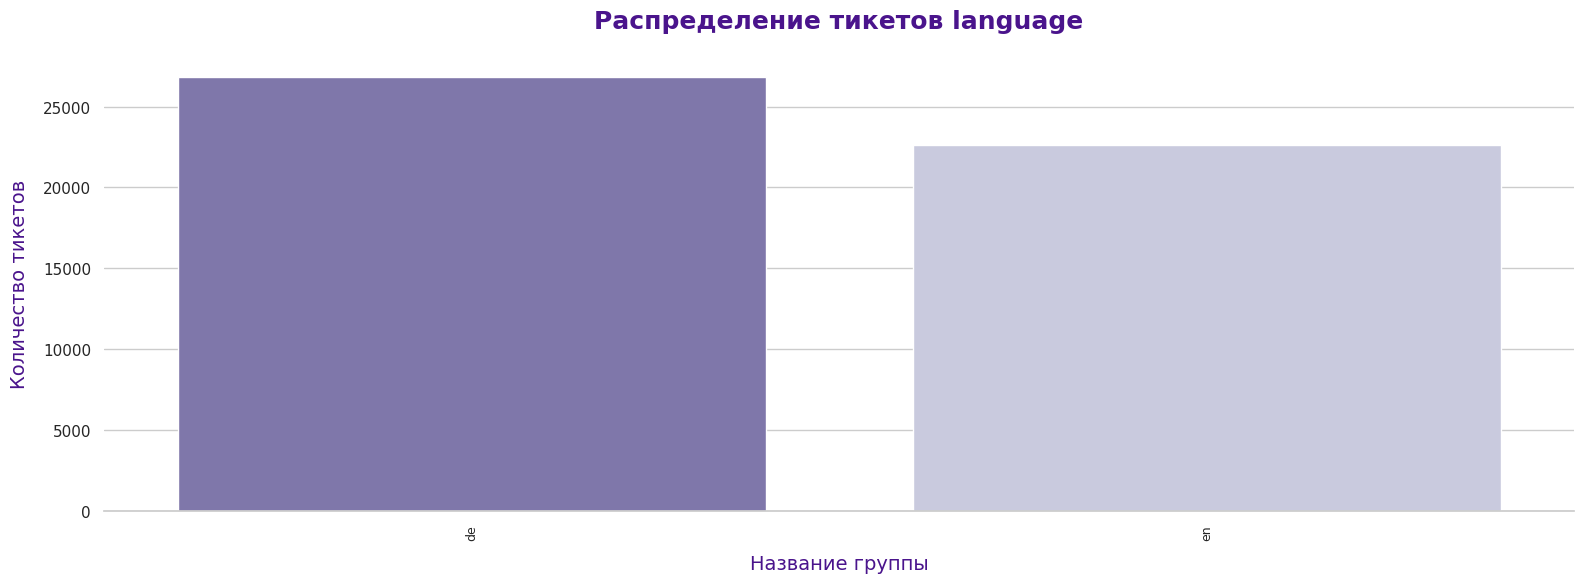

In [27]:
nclass = splits['train']['language'].value_counts()
plt.figure(figsize=(16, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=nclass.index,
    y=nclass.values,
    hue=nclass.index,
    palette="Purples_r",
    legend=False
)

plt.title('Распределение тикетов language', fontsize=18, fontweight='bold', pad=20, color='#4a148c')
plt.xlabel('Название группы', fontsize=14, labelpad=10, color='#4a148c')
plt.ylabel('Количество тикетов', fontsize=14, labelpad=10, color='#4a148c')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=11)
sns.despine(top=True, right=True, left=True)
plt.tight_layout()
plt.show()

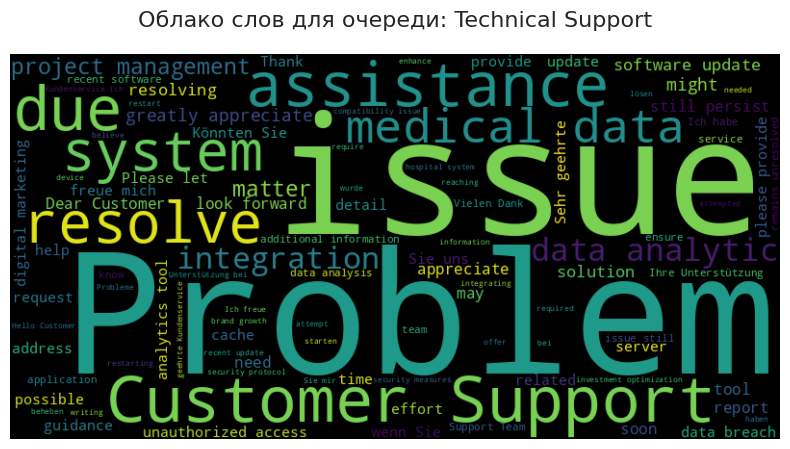

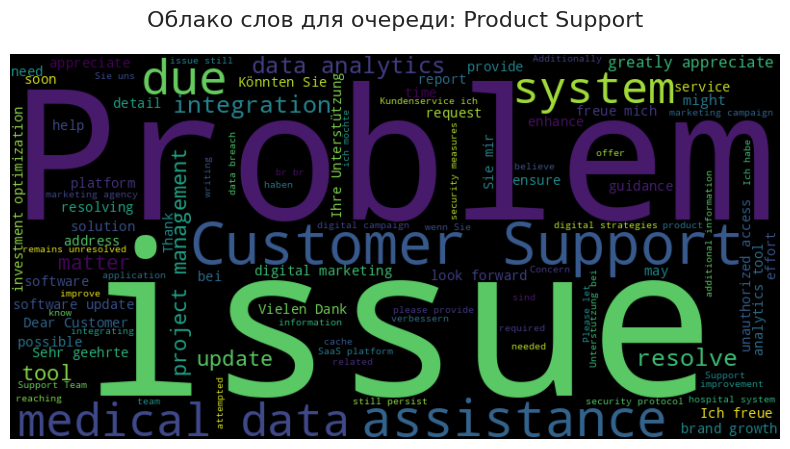

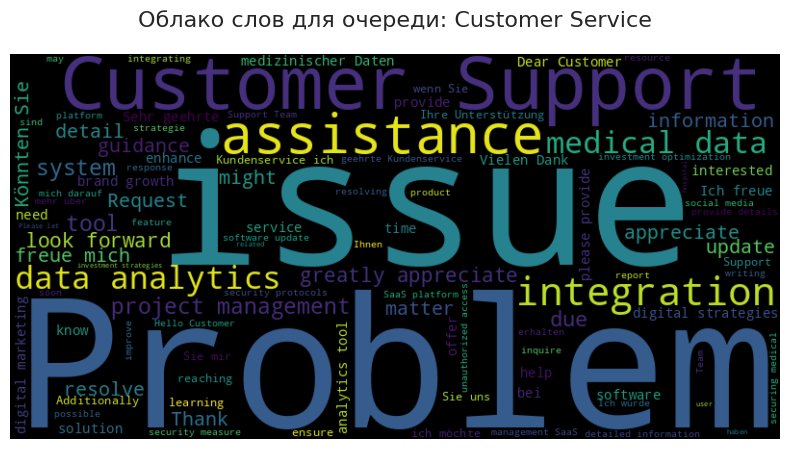

In [29]:
# train_df = splits['train']

top_2_queues = train['queue'].value_counts().head(3).index.tolist()
queue_1 = top_2_queues[0]
queue_2 = top_2_queues[1]
queue_3 = top_2_queues[2]

custom_stopwords = set(STOPWORDS)
german_stopwords = {
    "und", "die", "der", "das", "ist", "in", "zu", "den", "für", "von",
    "mit", "auf", "sich", "als", "auch", "es", "an", "werden", "aus", "wir",
    "bitte", "im", "am", "um", "nicht", "ein", "eine", "einer", "einen", "dem"
}
custom_stopwords.update(german_stopwords)


def plot_wordcloud(queue_name):
    subset = train[train['queue'] == queue_name]
    text_series = subset['subject'].fillna('') + " " + subset['body'].fillna('')
    full_text = " ".join(text_series.astype(str).tolist())

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='black',
        stopwords=custom_stopwords,
        max_words=100,
        colormap='viridis'
    ).generate(full_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f'Облако слов для очереди: {queue_name}', fontsize=16, pad=20)
    plt.show()

plot_wordcloud(queue_1)
plot_wordcloud(queue_2)
plot_wordcloud(queue_3)

В трех наиболее крупных группах queue наблюдается доминация одних и тех же слов

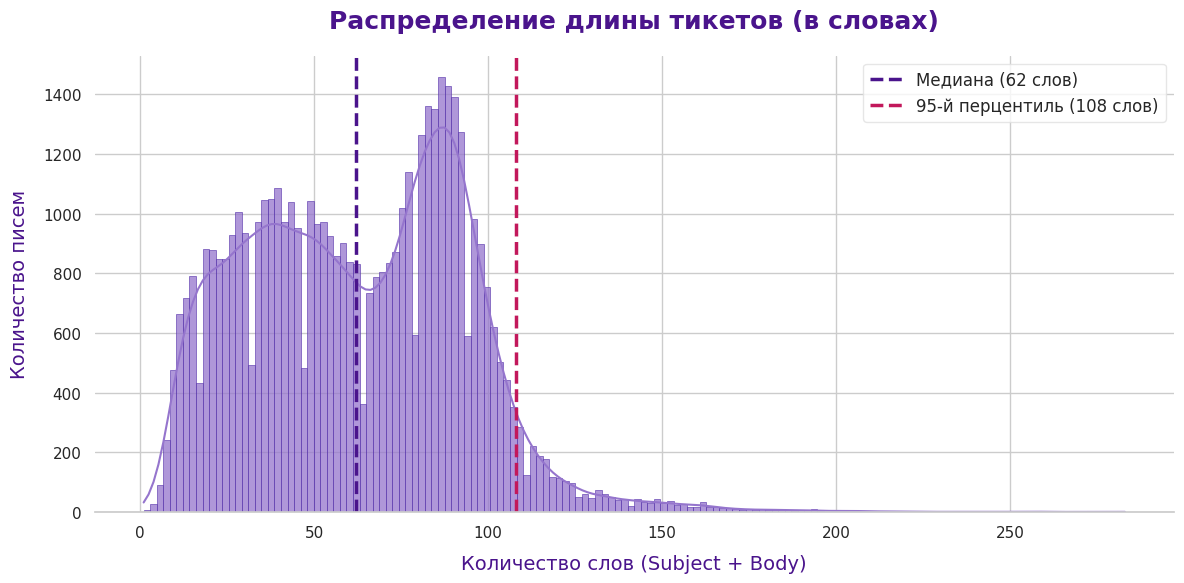

In [31]:
#df = splits['train'] # Используем наш сплит
texts = (train["subject"].fillna("") + " " + train["body"].fillna("")).astype(str)
word_counts = texts.str.split().map(len)

median_len = word_counts.median()
p95_len = word_counts.quantile(0.95)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.histplot(
    word_counts,
    bins=150,
    color='#9575cd',
    edgecolor='#512da8',
    kde=True,
    alpha=0.75
)

plt.axvline(median_len, color='#4a148c', linestyle='--', linewidth=2.5,
            label=f'Медиана ({median_len:.0f} слов)')

plt.axvline(p95_len, color='#c2185b', linestyle='--', linewidth=2.5,
            label=f'95-й перцентиль ({p95_len:.0f} слов)')


plt.title('Распределение длины тикетов (в словах)', fontsize=18, fontweight='bold', pad=20, color='#4a148c')
plt.xlabel('Количество слов (Subject + Body)', fontsize=14, labelpad=10, color='#4a148c')
plt.ylabel('Количество писем', fontsize=14, labelpad=10, color='#4a148c')
sns.despine(top=True, right=True, left=True)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=12, frameon=True, facecolor='white', edgecolor='#e0e0e0', shadow=False)

plt.tight_layout()
plt.show()

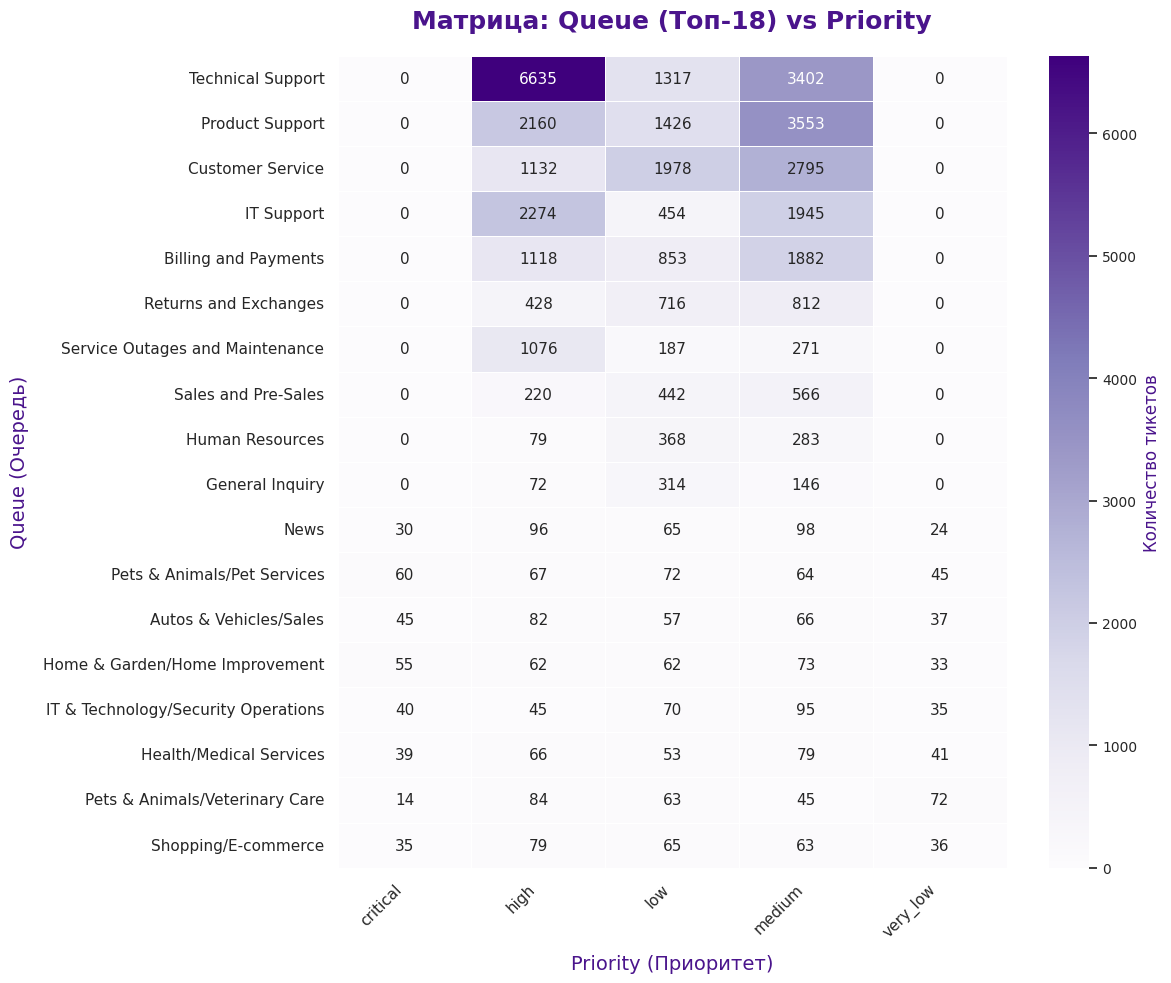

In [32]:
cross_tab = pd.crosstab(train['queue'], train['priority'])

cross_tab['Total'] = cross_tab.sum(axis=1)
cross_tab = cross_tab.sort_values(by='Total', ascending=False)
cross_tab = cross_tab.drop(columns='Total')
cross_tab_top18 = cross_tab.head(18)
plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    cross_tab_top18,
    annot=True,
    fmt='d',
    cmap='Purples',
    linewidths=.5,
    linecolor='white',
    cbar_kws={'label': 'Количество тикетов'},
    annot_kws={'size': 11}
)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('#4a148c')
cbar.ax.yaxis.label.set_size(12)
cbar.ax.tick_params(labelsize=10)
plt.title('Матрица: Queue (Топ-18) vs Priority', fontsize=18, fontweight='bold', pad=20, color='#4a148c')
plt.xlabel('Priority (Приоритет)', fontsize=14, labelpad=10, color='#4a148c')
plt.ylabel('Queue (Очередь)', fontsize=14, labelpad=10, color='#4a148c')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

## Baseline: TF-IDF + linear SVC

In [33]:
def baseline_tfidf_linear_svm(splits: dict[str, pd.DataFrame]) -> None:
    # Build text
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    vec = TfidfVectorizer(
        max_features=200_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    results = {}

    print("\n=== BASELINE: TF-IDF + LinearSVC ===")
    for target in ["queue", "priority", "type"]:
        ytr = splits["train"][target].astype(str).values
        yte = splits["test"][target].astype(str).values

        clf = LinearSVC()
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)

        acc = float(accuracy_score(yte, pred))
        if target == "queue":
            mf1 = float(f1_score(yte, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
            print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
        else:
            results[f"{target}_acc"] = acc
            print(f"{target}: acc={acc:.4f}")

    # final score (по вашей формуле)
    score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
    print("\n=== FINAL SCORE (baseline) ===")
    print(f"Score = {score:.4f}  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))")


In [34]:
baseline_tfidf_linear_svm(splits)


=== BASELINE: TF-IDF + LinearSVC ===
queue: acc=0.6901  macro_f1=0.8939
priority: acc=0.7112
type: acc=0.8969

=== FINAL SCORE (baseline) ===
Score = 0.8669  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))


## Transformer fine-tuning на multitask

In [4]:
for split_name in ['train', 'val', 'test']:
    df = splits[split_name]
    df['text'] = df['subject'].fillna('') + " </s> " + df['body'].fillna('')

le_queue = LabelEncoder()
le_priority = LabelEncoder()
le_type = LabelEncoder()

all_df = pd.concat([splits['train'], splits['val'], splits['test']])
le_queue.fit(all_df['queue'].astype(str))
le_priority.fit(all_df['priority'].astype(str))
le_type.fit(all_df['type'].astype(str))

for split_name in ['train', 'val', 'test']:
    splits[split_name]['label_queue'] = le_queue.transform(splits[split_name]['queue'].astype(str))
    splits[split_name]['label_priority'] = le_priority.transform(splits[split_name]['priority'].astype(str))
    splits[split_name]['label_type'] = le_type.transform(splits[split_name]['type'].astype(str))

print(f"Классов Queue: {len(le_queue.classes_)}")
print(f"Классов Priority: {len(le_priority.classes_)}")
print(f"Классов Type: {len(le_type.classes_)}")

MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

hf_datasets = {}
for split in ['train', 'val', 'test']:
    tmp_df = splits[split][['text', 'label_queue', 'label_priority', 'label_type']]
    hf_ds = Dataset.from_pandas(tmp_df)
    hf_datasets[split] = hf_ds.map(tokenize_function, batched=True)

for split in ['train', 'val', 'test']:
    hf_datasets[split].set_format(
        type='torch',
        columns=['input_ids', 'attention_mask', 'label_queue', 'label_priority', 'label_type']
    )

class MultitaskModel(nn.Module):
    def __init__(self, model_name, num_queues, num_priorities, num_types):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        hidden_size = self.roberta.config.hidden_size
        self.dropout = nn.Dropout(0.2)

        self.classifier_queue = nn.Linear(hidden_size, num_queues)
        self.classifier_priority = nn.Linear(hidden_size, num_priorities)
        self.classifier_type = nn.Linear(hidden_size, num_types)

    def forward(self, input_ids, attention_mask, **kwargs):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits_queue = self.classifier_queue(pooled_output)
        logits_priority = self.classifier_priority(pooled_output)
        logits_type = self.classifier_type(pooled_output)

        return logits_queue, logits_priority, logits_type

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultitaskModel(
    MODEL_NAME,
    num_queues=len(le_queue.classes_),
    num_priorities=len(le_priority.classes_),
    num_types=len(le_type.classes_)
).to(device)

Классов Queue: 52
Классов Priority: 5
Классов Type: 5


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
class MultitaskTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_queue = inputs["label_queue"]
        labels_priority = inputs["label_priority"]
        labels_type = inputs["label_type"]
        logits_queue, logits_priority, logits_type = model(**inputs)

        loss_fct = nn.CrossEntropyLoss()
        loss_q = loss_fct(logits_queue, labels_queue)
        loss_p = loss_fct(logits_priority, labels_priority)
        loss_t = loss_fct(logits_type, labels_type)
        total_loss = 0.70 * loss_q + 0.15 * loss_p + 0.15 * loss_t


        if return_outputs:
            return total_loss, (logits_queue, logits_priority, logits_type)
        return total_loss

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    remove_unused_columns=False,
    label_names=["label_queue", "label_priority", "label_type"]
)

trainer = MultitaskTrainer(
    model=model,
    args=training_args,
    train_dataset=hf_datasets['train'],
    eval_dataset=hf_datasets['val'])

print("Начинаем обучение Трансформера...")
trainer.train()

Начинаем обучение Трансформера...


Epoch,Training Loss,Validation Loss
1,1.223962,1.181793
2,1.053217,1.057689
3,0.969910,1.023532


TrainOutput(global_step=9267, training_loss=1.2098662389885122, metrics={'train_runtime': 7729.4272, 'train_samples_per_second': 19.178, 'train_steps_per_second': 1.199, 'total_flos': 0.0, 'train_loss': 1.2098662389885122, 'epoch': 3.0})

In [15]:
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm


model.eval()

test_dataloader = DataLoader(hf_datasets['test'], batch_size=32)

true_q, true_p, true_t = [], [], []
pred_q, pred_p, pred_t = [], [], []

with torch.no_grad():
    for batch in tqdm(test_dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        true_q.extend(batch['label_queue'].numpy())
        true_p.extend(batch['label_priority'].numpy())
        true_t.extend(batch['label_type'].numpy())
        logits_q, logits_p, logits_t = model(input_ids, attention_mask)
        pred_q.extend(torch.argmax(logits_q, dim=1).cpu().numpy())
        pred_p.extend(torch.argmax(logits_p, dim=1).cpu().numpy())
        pred_t.extend(torch.argmax(logits_t, dim=1).cpu().numpy())

macro_f1_q = f1_score(true_q, pred_q, average='macro')

acc_q = accuracy_score(true_q, pred_q)
acc_p = accuracy_score(true_p, pred_p)
acc_t = accuracy_score(true_t, pred_t)

final_score = 0.70 * macro_f1_q + 0.15 * acc_p + 0.15 * acc_t

print(f"Macro-F1 (Queue):  {macro_f1_q:.4f}")
print(f"Accuracy (Priority): {acc_p:.4f}")
print(f"Accuracy (Type):   {acc_t:.4f}")
print("-" * 40)
print(f"FINAL SCORE:    {final_score:.4f} ")
print("-"*40)

  0%|          | 0/194 [00:00<?, ?it/s]

Macro-F1 (Queue):  0.8350
Accuracy (Priority): 0.5372
Accuracy (Type):   0.8402
----------------------------------------
FINAL SCORE:    0.7911 
----------------------------------------
